In [1]:
print("hello world")

hello world


In [2]:
from langgraph.graph import StateGraph, START, END  
from langchain_openai import ChatOpenAI

In [3]:
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
import os
load_dotenv(override=True)  # Load environment variables from .env file

True

In [13]:

def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

In [14]:
llm = get_groq_llm()

In [15]:
class LLMState(TypedDict): # Define the structure of the state that will be passed to the LLM
    question: str
    answer: str

In [16]:
def chat_llm(state: LLMState):
    question = state["question"]

    ##prompt:
    promt = f"Answer the following question: {question}"
    answer= llm.invoke(promt).content

    state["answer"] = answer
    return state


In [17]:
graph = StateGraph(LLMState)

## add nodes
graph.add_node("chat_llm", chat_llm)

In [18]:
## Add edges
graph.add_edge(START, "chat_llm")
graph.add_edge("chat_llm", END)

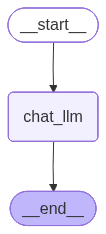

In [19]:
# Compilation of grph
workflow = graph.compile()

workflow

In [20]:
## Inference
initial_state = {"question": "What is the capital of France?"}
final_state= workflow.invoke(initial_state)
print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}


In [21]:
initial_state = {"question": "What is the capital of France?"}
final_state= workflow.invoke(initial_state)